# Exploratory Data Analysis (EDA)
## Customer Data Dataset - 25,000 Records

This notebook performs comprehensive exploratory data analysis on the customer dataset to understand:
- Data quality and completeness
- Distribution of key metrics
- Relationships between variables
- Business insights for renewal and upsell opportunities

In [1]:
!uv add ipynb matplotlib numpy openpyxl pandas seaborn

Resolved 48 packages in 1ms
Audited 42 packages in 127ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
data_path = Path("customer_data_25000.xlsx")
df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


## 1. Dataset Overview & Basic Information

In [4]:
# Basic information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n{'=' * 80}")
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

DATASET INFORMATION

Total Records: 24,874
Total Columns: 27

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

DATA TYPES
name                          str
domain                        str
industry                      str
company_size                  str
arr                         int64
mrr                       float64
contract_start_date           str
contract_end_date             str
renewal_date                  str
last_contact_date             str
status                        st

In [5]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Count', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found in the dataset!")

print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

MISSING VALUES ANALYSIS
       Column  Missing Count  Missing Percentage
salesforce_id           7501           30.155986

Total missing values: 7,501


In [6]:
# Check for duplicate records
print("=" * 80)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 80)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count:,}")

# Check for duplicate salesforce_id (should be unique)
if 'salesforce_id' in df.columns:
    duplicate_sf_ids = df['salesforce_id'].duplicated().sum()
    print(f"Duplicate salesforce_id: {duplicate_sf_ids:,}")

# Check for duplicate emails (should be unique)
if 'email' in df.columns:
    duplicate_emails = df['email'].duplicated().sum()
    print(f"Duplicate emails: {duplicate_emails:,}")

DUPLICATE RECORDS ANALYSIS
Total duplicate rows: 0
Duplicate salesforce_id: 7,556


## 2. Statistical Summary

In [7]:
# Statistical summary for numerical columns
print("=" * 80)
print("STATISTICAL SUMMARY - NUMERICAL COLUMNS")
print("=" * 80)

# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Columns: {', '.join(numerical_cols)}")

if len(numerical_cols) > 0:
    display(df[numerical_cols].describe().T)

STATISTICAL SUMMARY - NUMERICAL COLUMNS

Numerical columns: 10
Columns: arr, mrr, health_score, risk_score, relationship_score, churn_probability, sentiment_score, licenses_total, licenses_used, utilization_percentage


,count,mean,std,min,25%,50%,75%,max
arr,24874.0,208891.058495,148417.191414,15019.0000,89990.500000,170628.00000,284333.7500,549999.0000
mrr,24874.0,17407.588207,12368.099275,1251.5800,7499.210000,14219.00000,23694.4800,45833.2500
health_score,24874.0,70.217778,17.780470,30.0000,58.000000,72.00000,83.0000,100.0000
risk_score,24874.0,40.251628,21.742285,5.0000,23.000000,37.00000,55.0000,90.0000
relationship_score,24874.0,68.826727,19.149438,25.0000,56.000000,72.00000,83.0000,100.0000
churn_probability,24874.0,0.391903,0.213066,0.0500,0.227125,0.34390,0.5382,0.8500
sentiment_score,24874.0,0.390492,0.438628,-0.9994,0.098725,0.47755,0.7382,0.9999
licenses_total,24874.0,79.457265,62.846458,10.0000,30.000000,75.00000,150.0000,200.0000
licenses_used,24874.0,47.376498,43.275352,2.0000,14.000000,33.00000,68.0000,190.0000
utilization_percentage,24874.0,59.956260,20.503779,25.0000,42.000000,60.00000,78.0000,95.0000


In [8]:
# Statistical summary for categorical columns
print("=" * 80)
print("STATISTICAL SUMMARY - CATEGORICAL COLUMNS")
print("=" * 80)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Columns: {', '.join(categorical_cols)}")

if len(categorical_cols) > 0:
    for col in categorical_cols[:10]:  # Show first 10 to avoid too much output
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        if df[col].nunique() <= 20:
            print(f"  Value counts:")
            print(df[col].value_counts().head(10))

STATISTICAL SUMMARY - CATEGORICAL COLUMNS

Categorical columns: 17
Columns: name, domain, industry, company_size, contract_start_date, contract_end_date, renewal_date, last_contact_date, status, renewal_stage, sentiment_category, csm_name, csm_email, primary_contact_name, primary_contact_email, primary_contact_phone, salesforce_id

name:
  Unique values: 19745

domain:
  Unique values: 19745

industry:
  Unique values: 16
  Value counts:
industry
Analytics      1613
Research       1611
Technology     1592
Cloud          1585
Finance        1578
SaaS           1574
Retail         1569
Enterprise     1568
Real Estate    1557
Consulting     1550
Name: count, dtype: int64

company_size:
  Unique values: 4
  Value counts:
company_size
Small         6346
Large         6258
Medium        6211
Enterprise    6059
Name: count, dtype: int64

contract_start_date:
  Unique values: 91

contract_end_date:
  Unique values: 91

renewal_date:
  Unique values: 91

last_contact_date:
  Unique values: 372


## 3. Revenue Analysis (ARR & MRR)

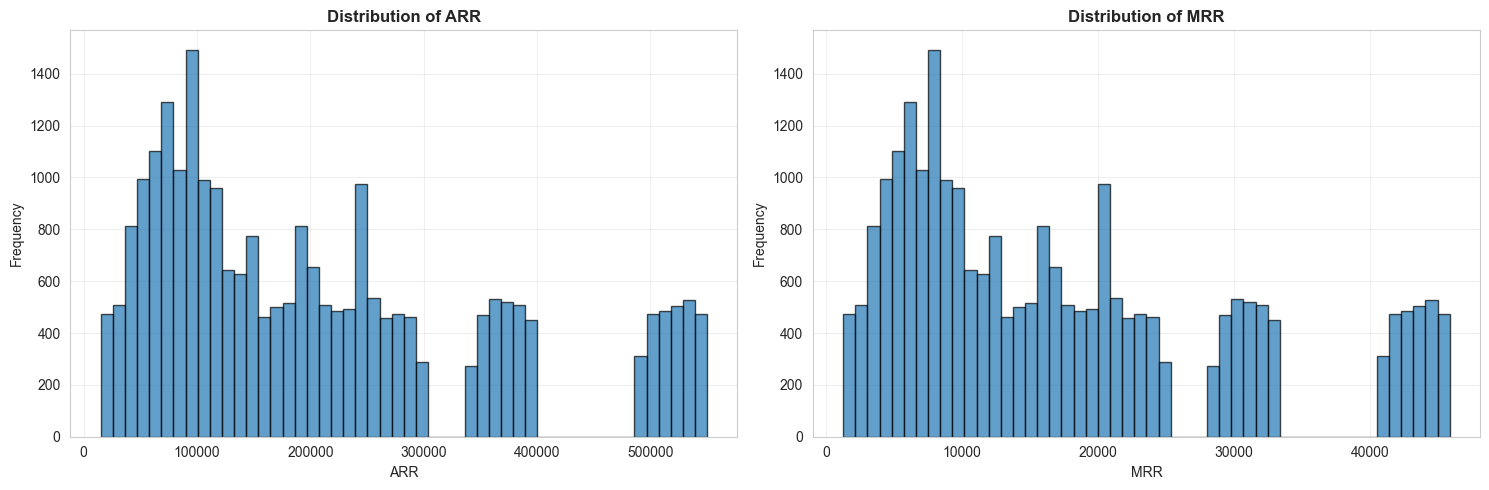


Revenue Summary Statistics:
                 arr           mrr
count   24874.000000  24874.000000
mean   208891.058495  17407.588207
std    148417.191414  12368.099275
min     15019.000000   1251.580000
25%     89990.500000   7499.210000
50%    170628.000000  14219.000000
75%    284333.750000  23694.480000
max    549999.000000  45833.250000


In [9]:
# Revenue metrics analysis
revenue_cols = ['arr', 'mrr']
available_revenue_cols = [col for col in revenue_cols if col in df.columns]

if available_revenue_cols:
    fig, axes = plt.subplots(1, len(available_revenue_cols), figsize=(15, 5))
    if len(available_revenue_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(available_revenue_cols):
        # Remove outliers for better visualization (using IQR method)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        filtered_data = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)][col]
        
        axes[idx].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col.upper()}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col.upper(), fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nRevenue Summary Statistics:")
    print(df[available_revenue_cols].describe())

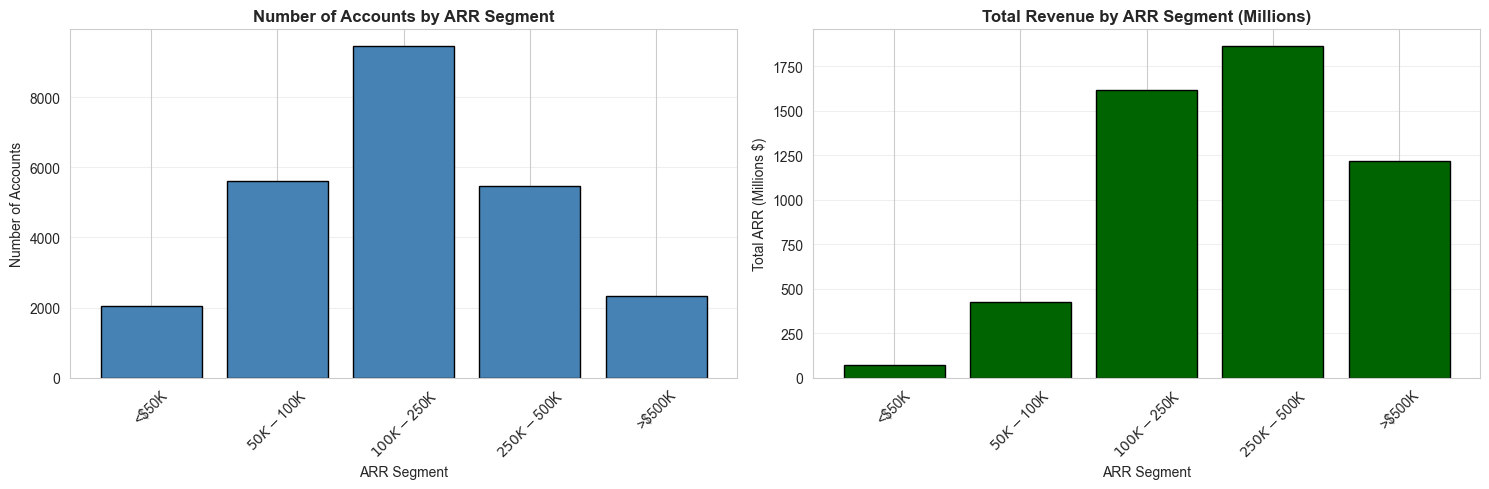


ARR Segment Distribution:
arr_segment
<$50K          2042
$50K-$100K     5595
$100K-$250K    9459
$250K-$500K    5460
>$500K         2318
Name: count, dtype: int64


In [10]:
# Revenue distribution by segments
if 'arr' in df.columns:
    # Create revenue segments
    df['arr_segment'] = pd.cut(df['arr'], 
                               bins=[0, 50000, 100000, 250000, 500000, float('inf')],
                               labels=['<$50K', '$50K-$100K', '$100K-$250K', '$250K-$500K', '>$500K'])
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Count plot
    arr_counts = df['arr_segment'].value_counts().sort_index()
    axes[0].bar(arr_counts.index, arr_counts.values, color='steelblue', edgecolor='black')
    axes[0].set_title('Number of Accounts by ARR Segment', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('ARR Segment', fontsize=10)
    axes[0].set_ylabel('Number of Accounts', fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Total revenue by segment
    arr_total = df.groupby('arr_segment')['arr'].sum().sort_index()
    axes[1].bar(arr_total.index, arr_total.values / 1e6, color='darkgreen', edgecolor='black')
    axes[1].set_title('Total Revenue by ARR Segment (Millions)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('ARR Segment', fontsize=10)
    axes[1].set_ylabel('Total ARR (Millions $)', fontsize=10)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\nARR Segment Distribution:")
    print(df['arr_segment'].value_counts().sort_index())

## 4. Health & Risk Scores Analysis

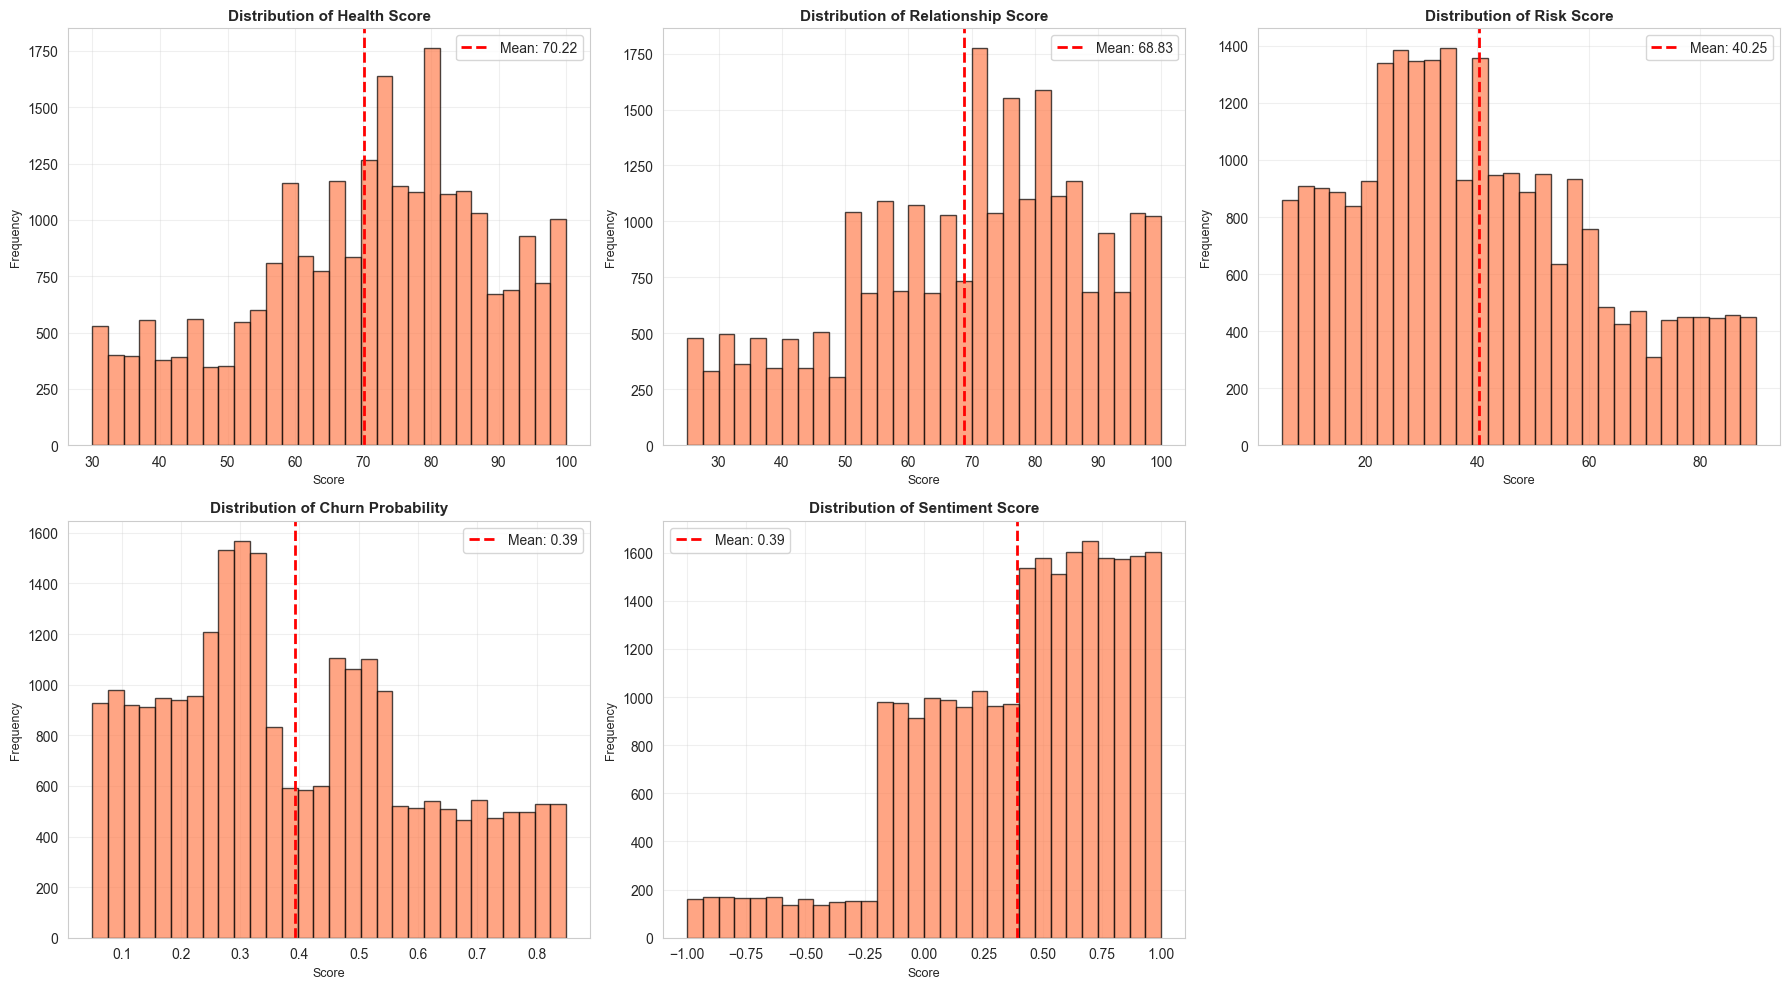


Score Summary Statistics:
       health_score  relationship_score    risk_score  churn_probability  \
count  24874.000000        24874.000000  24874.000000       24874.000000   
mean      70.217778           68.826727     40.251628           0.391903   
std       17.780470           19.149438     21.742285           0.213066   
min       30.000000           25.000000      5.000000           0.050000   
25%       58.000000           56.000000     23.000000           0.227125   
50%       72.000000           72.000000     37.000000           0.343900   
75%       83.000000           83.000000     55.000000           0.538200   
max      100.000000          100.000000     90.000000           0.850000   

       sentiment_score  
count     24874.000000  
mean          0.390492  
std           0.438628  
min          -0.999400  
25%           0.098725  
50%           0.477550  
75%           0.738200  
max           0.999900  


In [11]:
# Health and risk scores
score_cols = ['health_score', 'relationship_score', 'risk_score', 'churn_probability', 'sentiment_score']
available_score_cols = [col for col in score_cols if col in df.columns]

if available_score_cols:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(available_score_cols):
        if idx < len(axes):
            axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='coral')
            axes[idx].set_title(f'Distribution of {col.replace("_", " ").title()}', 
                               fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Score', fontsize=9)
            axes[idx].set_ylabel('Frequency', fontsize=9)
            axes[idx].grid(True, alpha=0.3)
            
            # Add mean line
            mean_val = df[col].mean()
            axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                            label=f'Mean: {mean_val:.2f}')
            axes[idx].legend()
    
    # Hide unused subplots
    for idx in range(len(available_score_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nScore Summary Statistics:")
    print(df[available_score_cols].describe())

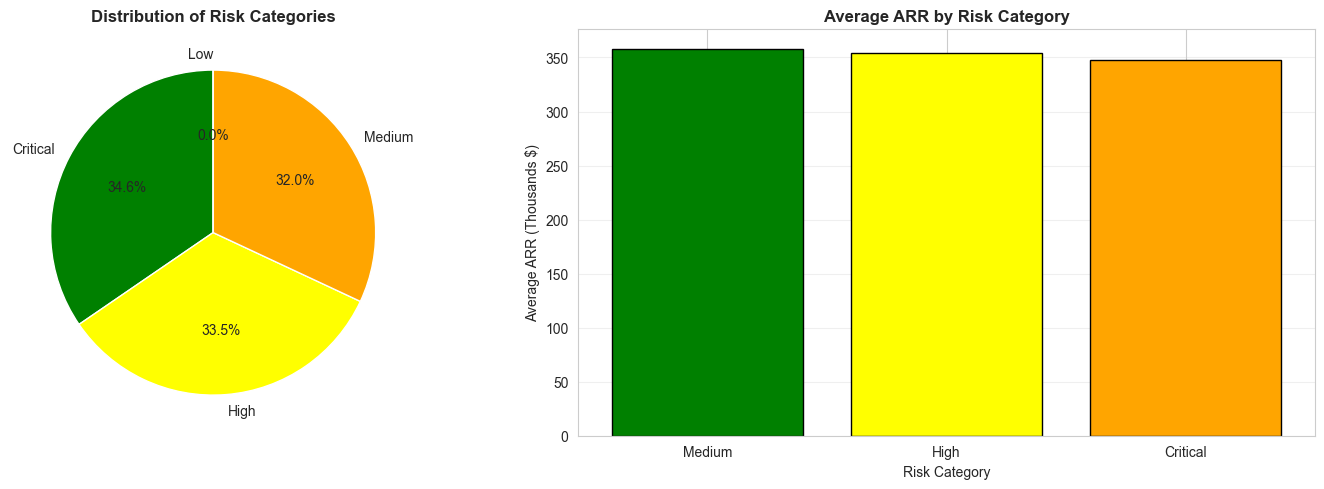


Risk Category Distribution:
risk_category
Critical    612
High        593
Medium      566
Low           0
Name: count, dtype: int64


In [12]:
# Risk categorization
if 'risk_score' in df.columns:
    df['risk_category'] = pd.cut(df['risk_score'], 
                                 bins=[0, 3, 6, 8, 10],
                                 labels=['Low', 'Medium', 'High', 'Critical'])
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Risk distribution
    risk_counts = df['risk_category'].value_counts()
    colors = ['green', 'yellow', 'orange', 'red']
    axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
               colors=colors[:len(risk_counts)], startangle=90)
    axes[0].set_title('Distribution of Risk Categories', fontsize=12, fontweight='bold')
    
    # Risk vs ARR
    risk_arr = df.groupby('risk_category')['arr'].mean() if 'arr' in df.columns else None
    if risk_arr is not None:
        axes[1].bar(risk_arr.index, risk_arr.values / 1000, color=colors[:len(risk_arr)], 
                   edgecolor='black')
        axes[1].set_title('Average ARR by Risk Category', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Risk Category', fontsize=10)
        axes[1].set_ylabel('Average ARR (Thousands $)', fontsize=10)
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\nRisk Category Distribution:")
    print(df['risk_category'].value_counts())

## 5. License Utilization Analysis

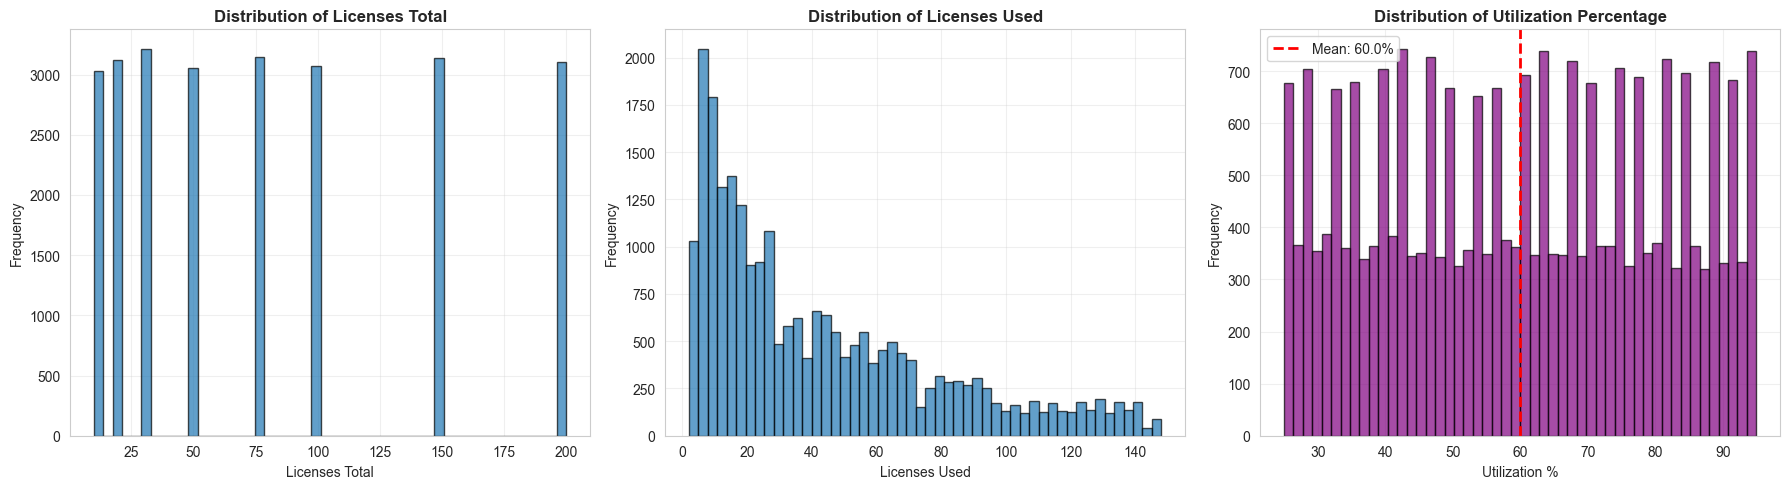


Utilization Insights:
Average Utilization: 59.96%
Median Utilization: 60.00%

Utilization Categories:
utilization_category
Low (<50%)          9167
Medium (50-75%)     8738
High (75-90%)       5213
Very High (>90%)    1756
Name: count, dtype: int64


In [13]:
# License utilization analysis
license_cols = ['licenses_total', 'licenses_used', 'utilization_percentage']
available_license_cols = [col for col in license_cols if col in df.columns]

if available_license_cols:
    fig, axes = plt.subplots(1, len(available_license_cols), figsize=(18, 5))
    if len(available_license_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(available_license_cols):
        if col == 'utilization_percentage':
            axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
            axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, 
                            label=f'Mean: {df[col].mean():.1f}%')
            axes[idx].set_xlabel('Utilization %', fontsize=10)
        else:
            # Remove outliers for better visualization
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = max(0, Q1 - 1.5 * IQR)
            upper_bound = Q3 + 1.5 * IQR
            
            filtered_data = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)][col]
            axes[idx].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
            axes[idx].set_xlabel(col.replace('_', ' ').title(), fontsize=10)
        
        axes[idx].set_title(f'Distribution of {col.replace("_", " ").title()}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        if col == 'utilization_percentage':
            axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Utilization insights
    if 'utilization_percentage' in df.columns:
        print("\nUtilization Insights:")
        print(f"Average Utilization: {df['utilization_percentage'].mean():.2f}%")
        print(f"Median Utilization: {df['utilization_percentage'].median():.2f}%")
        print(f"\nUtilization Categories:")
        df['utilization_category'] = pd.cut(df['utilization_percentage'],
                                            bins=[0, 50, 75, 90, 100],
                                            labels=['Low (<50%)', 'Medium (50-75%)', 
                                                   'High (75-90%)', 'Very High (>90%)'])
        print(df['utilization_category'].value_counts().sort_index())

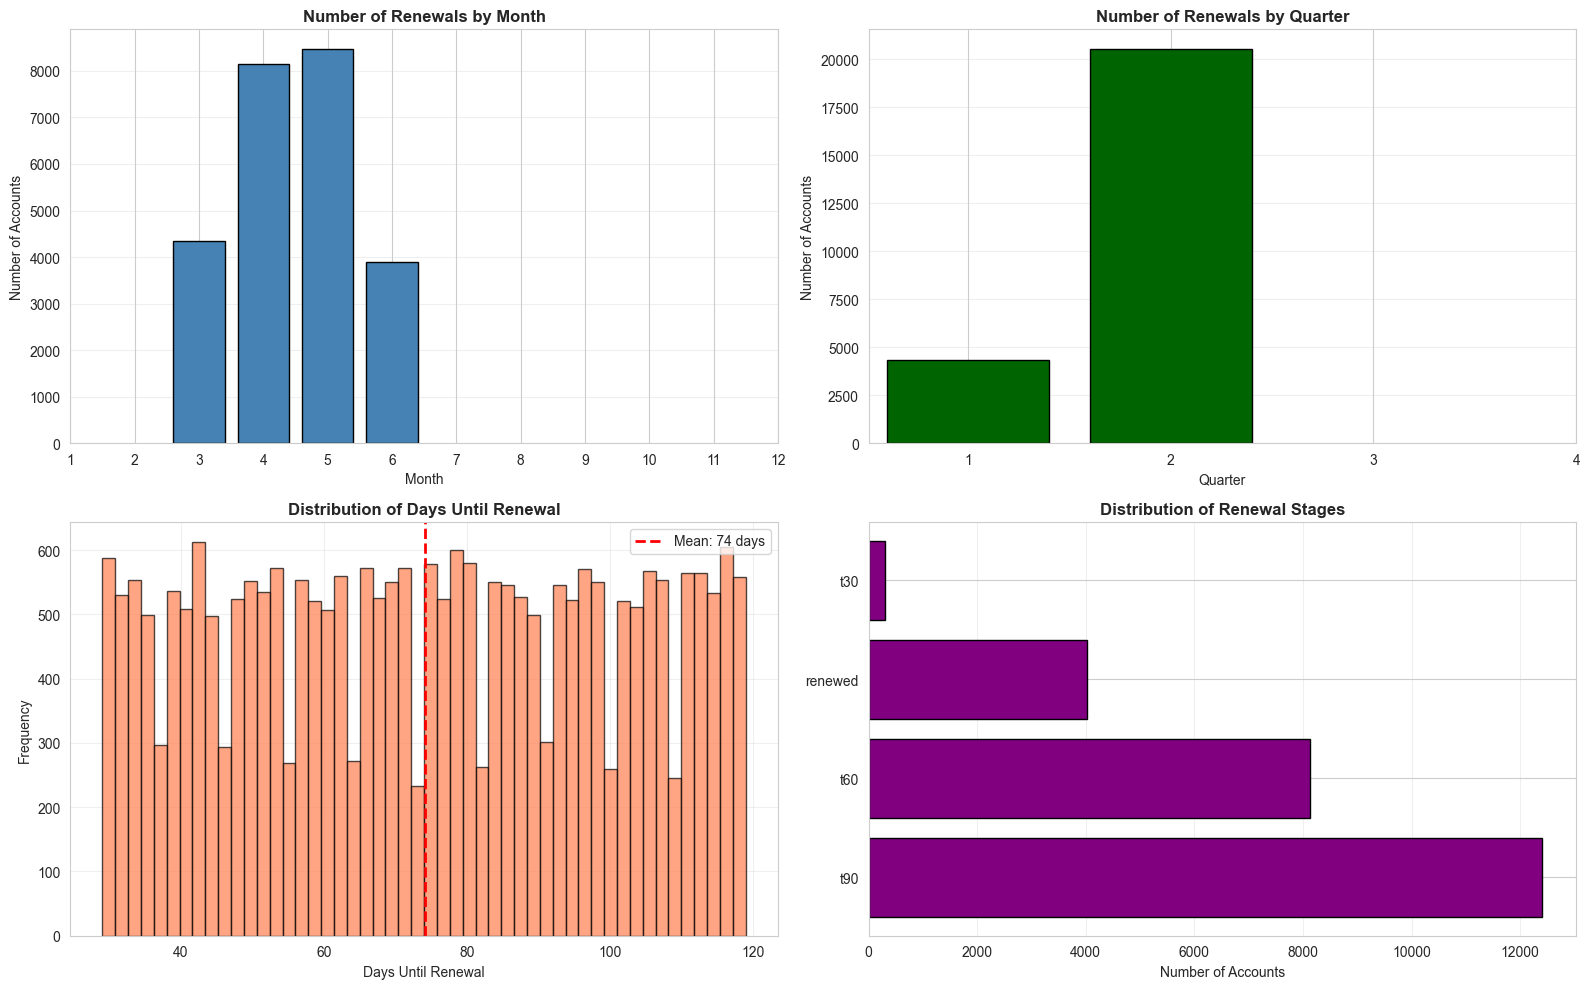


Renewal Insights:
Average days until renewal: 74 days
Accounts renewing in next 30 days: 588
Accounts renewing in next 90 days: 16,899


In [14]:
# Renewal date and stage analysis
if 'renewal_date' in df.columns:
    # Convert renewal_date to datetime
    df['renewal_date'] = pd.to_datetime(df['renewal_date'], errors='coerce')
    
    # Extract renewal month and year
    df['renewal_month'] = df['renewal_date'].dt.month
    df['renewal_year'] = df['renewal_date'].dt.year
    df['renewal_quarter'] = df['renewal_date'].dt.quarter
    
    # Calculate days until renewal
    today = pd.Timestamp.now()
    df['days_until_renewal'] = (df['renewal_date'] - today).dt.days
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Renewals by month
    renewal_by_month = df['renewal_month'].value_counts().sort_index()
    axes[0, 0].bar(renewal_by_month.index, renewal_by_month.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Number of Renewals by Month', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Month', fontsize=10)
    axes[0, 0].set_ylabel('Number of Accounts', fontsize=10)
    axes[0, 0].set_xticks(range(1, 13))
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Renewals by quarter
    renewal_by_quarter = df['renewal_quarter'].value_counts().sort_index()
    axes[0, 1].bar(renewal_by_quarter.index, renewal_by_quarter.values, color='darkgreen', edgecolor='black')
    axes[0, 1].set_title('Number of Renewals by Quarter', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Quarter', fontsize=10)
    axes[0, 1].set_ylabel('Number of Accounts', fontsize=10)
    axes[0, 1].set_xticks(range(1, 5))
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Days until renewal distribution
    valid_days = df['days_until_renewal'].dropna()
    axes[1, 0].hist(valid_days, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1, 0].axvline(valid_days.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {valid_days.mean():.0f} days')
    axes[1, 0].set_title('Distribution of Days Until Renewal', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Days Until Renewal', fontsize=10)
    axes[1, 0].set_ylabel('Frequency', fontsize=10)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Renewal stage distribution
    if 'renewal_stage' in df.columns:
        renewal_stage_counts = df['renewal_stage'].value_counts()
        axes[1, 1].barh(range(len(renewal_stage_counts)), renewal_stage_counts.values, 
                       color='purple', edgecolor='black')
        axes[1, 1].set_yticks(range(len(renewal_stage_counts)))
        axes[1, 1].set_yticklabels(renewal_stage_counts.index)
        axes[1, 1].set_title('Distribution of Renewal Stages', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Number of Accounts', fontsize=10)
        axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("\nRenewal Insights:")
    print(f"Average days until renewal: {valid_days.mean():.0f} days")
    print(f"Accounts renewing in next 30 days: {(valid_days <= 30).sum():,}")
    print(f"Accounts renewing in next 90 days: {(valid_days <= 90).sum():,}")

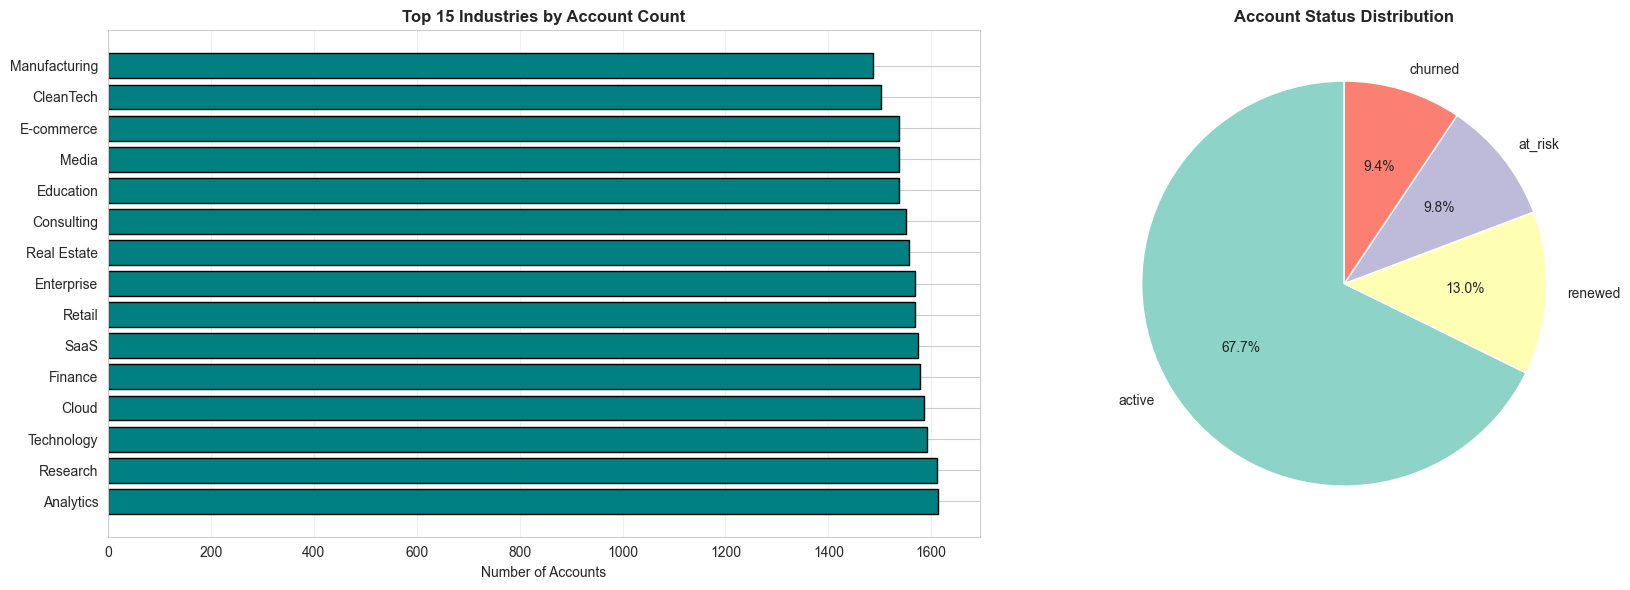


Top 10 Industries:
industry
Analytics      1613
Research       1611
Technology     1592
Cloud          1585
Finance        1578
SaaS           1574
Retail         1569
Enterprise     1568
Real Estate    1557
Consulting     1550
Name: count, dtype: int64


Account Status Distribution:
status
active     16847
renewed     3239
at_risk     2449
churned     2339
Name: count, dtype: int64


In [15]:
# Industry and status analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Industry distribution
if 'industry' in df.columns:
    industry_counts = df['industry'].value_counts().head(15)
    axes[0].barh(range(len(industry_counts)), industry_counts.values, color='teal', edgecolor='black')
    axes[0].set_yticks(range(len(industry_counts)))
    axes[0].set_yticklabels(industry_counts.index)
    axes[0].set_title('Top 15 Industries by Account Count', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Number of Accounts', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='x')

# Status distribution
if 'status' in df.columns:
    status_counts = df['status'].value_counts()
    colors = plt.cm.Set3(range(len(status_counts)))
    axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
    axes[1].set_title('Account Status Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top industries
if 'industry' in df.columns:
    print("\nTop 10 Industries:")
    print(df['industry'].value_counts().head(10))
    
if 'status' in df.columns:
    print("\n\nAccount Status Distribution:")
    print(df['status'].value_counts())

## 8. Correlation Analysis

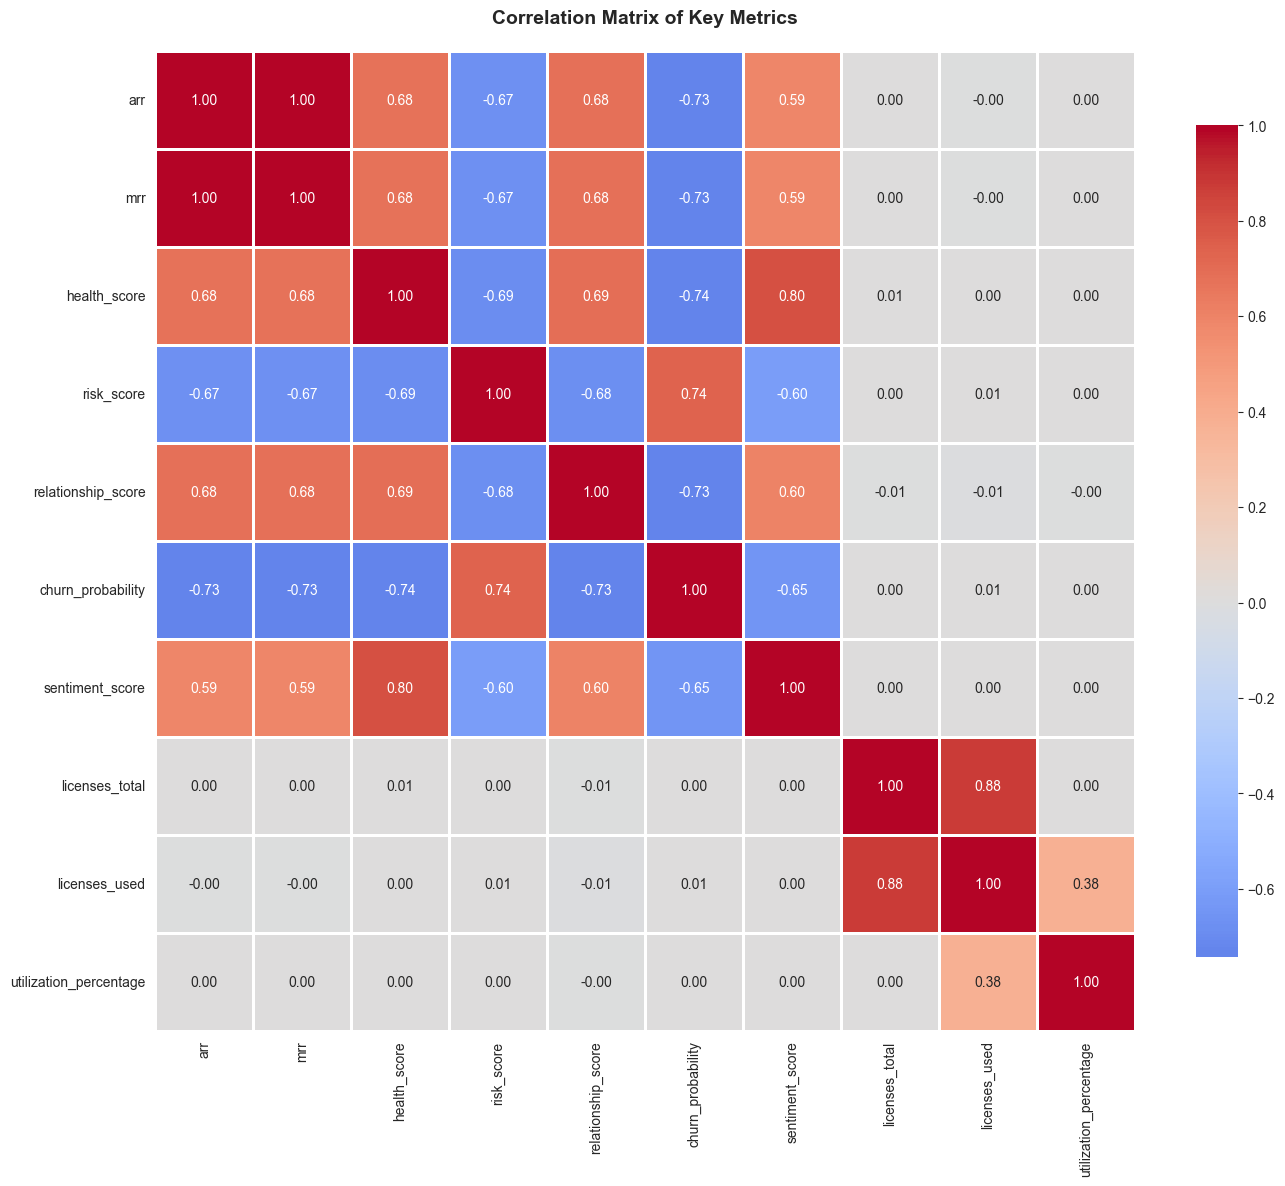


Strong Correlations (|r| > 0.5):
  arr ↔ mrr: 1.000
  arr ↔ health_score: 0.679
  arr ↔ risk_score: -0.672
  arr ↔ relationship_score: 0.682
  arr ↔ churn_probability: -0.732
  arr ↔ sentiment_score: 0.590
  mrr ↔ health_score: 0.679
  mrr ↔ risk_score: -0.672
  mrr ↔ relationship_score: 0.682
  mrr ↔ churn_probability: -0.732
  mrr ↔ sentiment_score: 0.590
  health_score ↔ risk_score: -0.689
  health_score ↔ relationship_score: 0.687
  health_score ↔ churn_probability: -0.742
  health_score ↔ sentiment_score: 0.804
  risk_score ↔ relationship_score: -0.680
  risk_score ↔ churn_probability: 0.738
  risk_score ↔ sentiment_score: -0.603
  relationship_score ↔ churn_probability: -0.734
  relationship_score ↔ sentiment_score: 0.603
  churn_probability ↔ sentiment_score: -0.651
  licenses_total ↔ licenses_used: 0.877


In [16]:
# Correlation matrix for numerical variables
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns and dates if present
exclude_cols = ['id', 'account_id', 'renewal_month', 'renewal_year', 'renewal_quarter', 'days_until_renewal']
correlation_cols = [col for col in numerical_cols if col not in exclude_cols]

if len(correlation_cols) > 1:
    corr_matrix = df[correlation_cols].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
               square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Find strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

## 9. Key Relationships & Insights

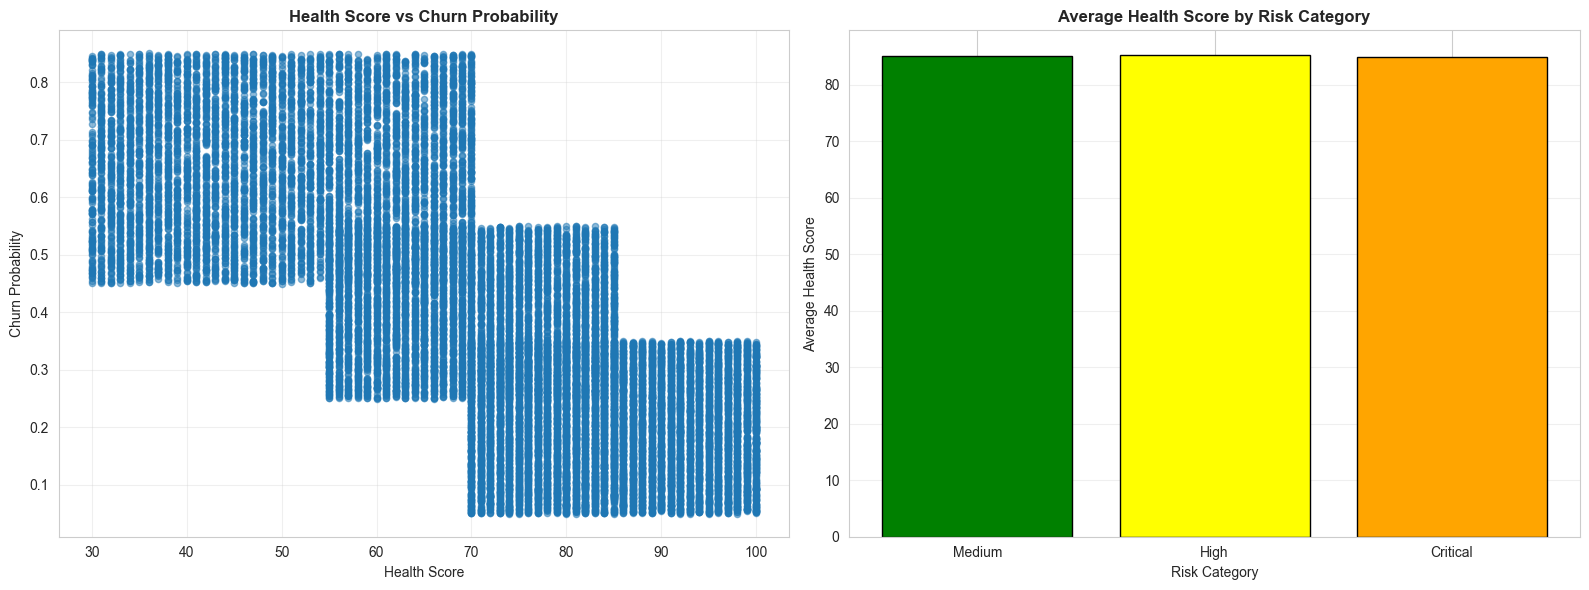


Correlation between Health Score and Churn Probability: -0.742


In [17]:
# Relationship between health score and churn probability
if 'health_score' in df.columns and 'churn_probability' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    axes[0].scatter(df['health_score'], df['churn_probability'], alpha=0.5, s=20)
    axes[0].set_xlabel('Health Score', fontsize=10)
    axes[0].set_ylabel('Churn Probability', fontsize=10)
    axes[0].set_title('Health Score vs Churn Probability', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Health score by risk category
    if 'risk_category' in df.columns:
        health_by_risk = df.groupby('risk_category')['health_score'].mean()
        axes[1].bar(health_by_risk.index, health_by_risk.values, color=['green', 'yellow', 'orange', 'red'][:len(health_by_risk)],
                   edgecolor='black')
        axes[1].set_xlabel('Risk Category', fontsize=10)
        axes[1].set_ylabel('Average Health Score', fontsize=10)
        axes[1].set_title('Average Health Score by Risk Category', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation
    if 'health_score' in df.columns and 'churn_probability' in df.columns:
        corr = df['health_score'].corr(df['churn_probability'])
        print(f"\nCorrelation between Health Score and Churn Probability: {corr:.3f}")

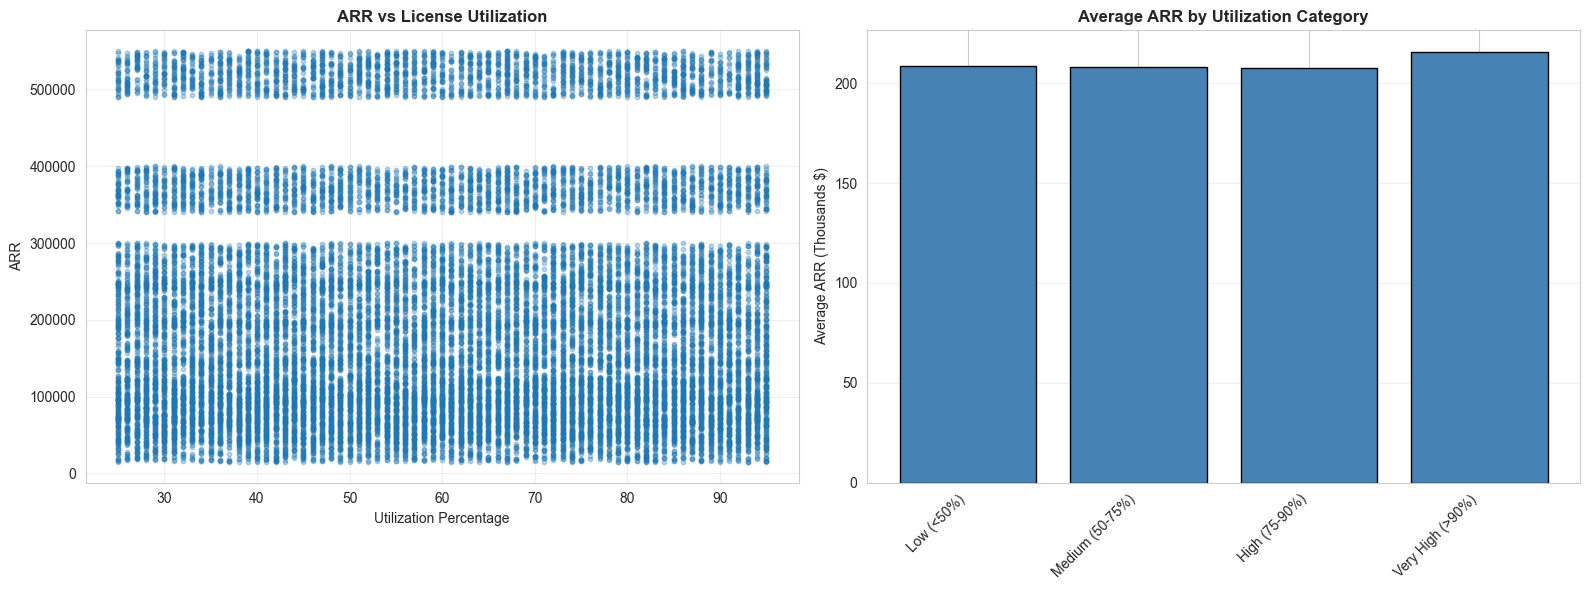

In [18]:
# ARR vs Utilization relationship
if 'arr' in df.columns and 'utilization_percentage' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    axes[0].scatter(df['utilization_percentage'], df['arr'], alpha=0.3, s=10)
    axes[0].set_xlabel('Utilization Percentage', fontsize=10)
    axes[0].set_ylabel('ARR', fontsize=10)
    axes[0].set_title('ARR vs License Utilization', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Average ARR by utilization category
    if 'utilization_category' in df.columns:
        arr_by_util = df.groupby('utilization_category')['arr'].mean()
        axes[1].bar(range(len(arr_by_util)), arr_by_util.values / 1000, 
                   color='steelblue', edgecolor='black')
        axes[1].set_xticks(range(len(arr_by_util)))
        axes[1].set_xticklabels(arr_by_util.index, rotation=45, ha='right')
        axes[1].set_ylabel('Average ARR (Thousands $)', fontsize=10)
        axes[1].set_title('Average ARR by Utilization Category', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 10. Business Insights & Summary

In [19]:
# Generate key business insights
print("=" * 80)
print("KEY BUSINESS INSIGHTS")
print("=" * 80)

# Total revenue
if 'arr' in df.columns:
    total_arr = df['arr'].sum()
    print(f"\n💰 Total ARR: ${total_arr:,.2f}")
    print(f"   Average ARR per account: ${df['arr'].mean():,.2f}")
    print(f"   Median ARR per account: ${df['arr'].median():,.2f}")

# High-risk accounts
if 'risk_category' in df.columns:
    high_risk = df[df['risk_category'].isin(['High', 'Critical'])]
    print(f"\n⚠️  High-Risk Accounts: {len(high_risk):,} ({len(high_risk)/len(df)*100:.1f}%)")
    if 'arr' in df.columns:
        high_risk_arr = high_risk['arr'].sum()
        print(f"   High-risk ARR: ${high_risk_arr:,.2f} ({high_risk_arr/total_arr*100:.1f}% of total)")

# Upcoming renewals
if 'days_until_renewal' in df.columns:
    upcoming_30 = df[(df['days_until_renewal'] >= 0) & (df['days_until_renewal'] <= 30)]
    upcoming_90 = df[(df['days_until_renewal'] >= 0) & (df['days_until_renewal'] <= 90)]
    print(f"\n📅 Upcoming Renewals:")
    print(f"   Next 30 days: {len(upcoming_30):,} accounts")
    if 'arr' in df.columns:
        print(f"   ARR at risk (30 days): ${upcoming_30['arr'].sum():,.2f}")
    print(f"   Next 90 days: {len(upcoming_90):,} accounts")
    if 'arr' in df.columns:
        print(f"   ARR at risk (90 days): ${upcoming_90['arr'].sum():,.2f}")

# Low utilization (upsell opportunity)
if 'utilization_percentage' in df.columns:
    low_util = df[df['utilization_percentage'] < 50]
    print(f"\n📈 Upsell Opportunities (Low Utilization <50%):")
    print(f"   Accounts: {len(low_util):,} ({len(low_util)/len(df)*100:.1f}%)")
    if 'arr' in df.columns:
        print(f"   Current ARR: ${low_util['arr'].sum():,.2f}")

# High churn probability
if 'churn_probability' in df.columns:
    high_churn = df[df['churn_probability'] > 0.7]
    print(f"\n🚨 High Churn Risk (Probability >70%):")
    print(f"   Accounts: {len(high_churn):,} ({len(high_churn)/len(df)*100:.1f}%)")
    if 'arr' in df.columns:
        print(f"   ARR at risk: ${high_churn['arr'].sum():,.2f}")

print("\n" + "=" * 80)

KEY BUSINESS INSIGHTS

💰 Total ARR: $5,195,956,189.00
   Average ARR per account: $208,891.06
   Median ARR per account: $170,628.00

⚠️  High-Risk Accounts: 1,205 (4.8%)
   High-risk ARR: $422,621,839.00 (8.1% of total)

📅 Upcoming Renewals:
   Next 30 days: 588 accounts
   ARR at risk (30 days): $128,699,009.00
   Next 90 days: 16,899 accounts
   ARR at risk (90 days): $3,520,083,340.00

📈 Upsell Opportunities (Low Utilization <50%):
   Accounts: 8,847 (35.6%)
   Current ARR: $1,848,668,752.00

🚨 High Churn Risk (Probability >70%):
   Accounts: 2,850 (11.5%)
   ARR at risk: $188,580,706.00



In [20]:
# Create summary statistics table
summary_data = {
    'Metric': [],
    'Value': []
}

if 'arr' in df.columns:
    summary_data['Metric'].extend(['Total ARR', 'Average ARR', 'Median ARR', 'Max ARR', 'Min ARR'])
    summary_data['Value'].extend([
        f"${df['arr'].sum():,.2f}",
        f"${df['arr'].mean():,.2f}",
        f"${df['arr'].median():,.2f}",
        f"${df['arr'].max():,.2f}",
        f"${df['arr'].min():,.2f}"
    ])

if 'health_score' in df.columns:
    summary_data['Metric'].extend(['Avg Health Score', 'Avg Relationship Score'])
    summary_data['Value'].extend([
        f"{df['health_score'].mean():.2f}",
        f"{df['relationship_score'].mean():.2f}" if 'relationship_score' in df.columns else "N/A"
    ])

if 'utilization_percentage' in df.columns:
    summary_data['Metric'].append('Average Utilization %')
    summary_data['Value'].append(f"{df['utilization_percentage'].mean():.2f}%")

if 'churn_probability' in df.columns:
    summary_data['Metric'].append('Average Churn Probability')
    summary_data['Value'].append(f"{df['churn_probability'].mean():.2%}")

summary_df = pd.DataFrame(summary_data)
print("\n📊 Summary Statistics:")
print(summary_df.to_string(index=False))


📊 Summary Statistics:
                   Metric             Value
                Total ARR $5,195,956,189.00
              Average ARR       $208,891.06
               Median ARR       $170,628.00
                  Max ARR       $549,999.00
                  Min ARR        $15,019.00
         Avg Health Score             70.22
   Avg Relationship Score             68.83
    Average Utilization %            59.96%
Average Churn Probability            39.19%


## 11. Data Quality Check

In [21]:
# Final data quality report
print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

print(f"\n✅ Total Records: {len(df):,}")
print(f"✅ Total Columns: {len(df.columns)}")
print(f"✅ Missing Values: {df.isnull().sum().sum():,}")
print(f"✅ Duplicate Rows: {df.duplicated().sum():,}")

# Check for data consistency
issues = []

if 'licenses_total' in df.columns and 'licenses_used' in df.columns:
    invalid_licenses = df[df['licenses_used'] > df['licenses_total']]
    if len(invalid_licenses) > 0:
        issues.append(f"⚠️  {len(invalid_licenses)} accounts have licenses_used > licenses_total")

if 'arr' in df.columns:
    negative_arr = df[df['arr'] < 0]
    if len(negative_arr) > 0:
        issues.append(f"⚠️  {len(negative_arr)} accounts have negative ARR")

if 'utilization_percentage' in df.columns:
    invalid_util = df[(df['utilization_percentage'] < 0) | (df['utilization_percentage'] > 100)]
    if len(invalid_util) > 0:
        issues.append(f"⚠️  {len(invalid_util)} accounts have utilization outside 0-100%")

if issues:
    print("\n⚠️  Data Quality Issues Found:")
    for issue in issues:
        print(f"   {issue}")
else:
    print("\n✅ No data quality issues detected!")

print("\n" + "=" * 80)
print("EDA Complete! 🎉")
print("=" * 80)

DATA QUALITY REPORT

✅ Total Records: 24,874
✅ Total Columns: 34
✅ Missing Values: 30,604
✅ Duplicate Rows: 0

✅ No data quality issues detected!

EDA Complete! 🎉
